# 07 · E1c: identifiability — why can't the ladder see deeper mechanisms?

**Where we are.**
* Notebooks 02 and 06 showed that E1 cannot detect L2 (intrinsic excitability), nor L3 (peptides) at realistic strength.
* Analyzing full time courses instead of window means did not help (Notebook 06: no rescue).
* In every synthetic run, the fitted *true* rung scored far below the oracle: held-out FEVE 0.56–0.98 against 1.00 for the true parameters.

**The question:** is that gap an **optimization** failure (the optimizer misses better solutions that exist), or an **identifiability** failure (many parameter settings fit the data equally well, but disagree about unseen interventions)? The two call for different remedies, and the answer constrains what E1, and later E3, can conclude.

| § | what | cost (`laptop`) |
|---|---|---|
| 1 | Training loss at the truth vs at the fit (reuses Notebook 06's fits) | minutes |
| 2 | **Sloppiness spectrum:** Fisher information at the truth; how many parameter combinations do window and time-course data constrain, and which mechanisms do they belong to? | minutes |
| 3 | **Ensemble estimator:** average several equally good fits. Does it recover held-out accuracy and the true rung? | ~1–2 h |
| 4 | Real data: the **sufficiency/necessity bracket** for E1, and the sloppiness of the real fitted L1 | ~20–40 min |

Background: sloppy models have Fisher eigenvalues spread evenly over many decades, so the data constrain only a few stiff parameter combinations (Gutenkunst et al. 2007, *PLoS Comput Biol* 3:e189). Machta et al. (2013, *Science* 342:604) argue that this compression is what makes simple emergent descriptions possible. That is directly relevant to whether a closed "software" level exists.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, time, datetime, pickle, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:2]) >= (0, 6), \
    f"Notebook 07 needs closurebench >= 0.6 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M, identifiability as ID
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {   # must match Notebook 06 so its fits are reused from the checkpoints
    "smoke":  dict(N_NEURONS=16,  REAL_WIRING=False, TRUTHS=["L1", "L2"], SEEDS=[1], K=2, STEPS=15, N_BOOT=100, MEMBERS=2, REAL_FISHER=False),
    "laptop": dict(N_NEURONS=60,  REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3"], SEEDS=[1], K=3, STEPS=250, N_BOOT=1000, MEMBERS=3, REAL_FISHER=True),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3", "L4"], SEEDS=[1, 2, 3], K=5, STEPS=500, N_BOOT=2000, MEMBERS=5, REAL_FISHER=True),
}[MODE]
globals().update(CONF)
N_BINS, PEPTIDE_SCALE = 10, 0.5
LEVELS = ["L0", "L1", "L2", "L3", "L4", "B"]; LADDER = ["L0", "L1", "L2", "L3", "L4"]
TAG = "" if MODE == "full" else f"_{MODE}"
cfg_w, cfg_b = lad.SimConfig(), lad.SimConfig(n_bins=N_BINS)
ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
if REAL_WIRING:
    mk = real.mask()[0]; score = mk.sum(1).astype(float); score[real.stim] += mk.sum(0)
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)
def worm(truth, seed):
    """The identical synthetic worm used in Notebook 06 (same seed, same noise)."""
    ds_b, p_true, R_b = lad.make_synthetic(template, true_level=truth, seed=seed, cfg=cfg_b, peptide_scale=PEPTIDE_SCALE)
    p_true = dict(p_true); p_true["stim_col"] = jnp.zeros(template.S)   # truth: exact stimulus, zero offsets
    return D.average_bins(ds_b), ds_b, p_true
def ck06(truth, seed, kind):
    return os.path.join(RESULTS, "e1b_synthetic_ck", MODE, f"{truth}_s{seed}_{kind}")
def ladder_fit(ds, cfg, ck, seed=0, fold_seed=0):
    return M.run_crossvalidated_ladder(ds, levels=LEVELS, k=K, steps=STEPS, lr=2e-2, cfg=cfg, equal_budget=True, restarts=3,
                                       checkpoint=ck, log=None, seed=seed, fold_seed=fold_seed)
print(template.summary())

Dataset: N=60 neurons, S=60 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 286  gap-junction pairs: 98  peptidergic pairs: 2214
  signs: +49 / -51 / unknown 186 (on existing synapses)
  wt: 3534 observed pairs, median trials 10
  unc31: 2401 observed pairs, median trials 2


### Pre-registration (before §3)

Recorded in `results/E1c_preregistration*.json`. Both estimators use the same folds and the same sufficiency rule as before; a hit is exact recovery of the true rung.

The **ensemble remedy works** if all three hold:
* for truths L2 and L3, the ensemble has more hits than the single fit;
* the ensemble never picks a rung deeper than the truth;
* the true rung's held-out FEVE is higher for the ensemble than for the single fit, for every truth.

Every result also reports the **necessity bracket**: L_needed ≤ closed ≤ L*.

In [3]:
prereg = os.path.join(RESULTS, f"E1c_preregistration{TAG}.json")
plan = {"experiment": "E1c identifiability and ensemble estimator", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "config": CONF,
        "hit": "exact recovery: L* (sufficiency rule) == true rung",
        "remedy_rule": "for truths L2, L3: ensemble hits > single hits; ensemble never deeper than truth; "
                       "true-rung held-out FEVE ensemble > single for every truth",
        "also_reported": "necessity bracket L_needed <= closed <= L* (metrics.necessity)"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1c_preregistration_laptop.json


## 1 · Optimization or identifiability?

For each synthetic worm and fold, compare the true parameters and the fitted true rung on:
* the **training loss** (the same weighted loss the fit minimizes, on the training pairs only);
* the **held-out FEVE**.

| pattern | meaning |
|---|---|
| truth's training loss < fit's | the optimizer failed to find a better solution that exists |
| equal training loss, much lower held-out FEVE for the fit | identifiability: the data do not pin the parameters down |

In [4]:
def train_loss(level, p, ds, st, cfg, train):
    P = np.asarray(lad.predict(level, jax.tree_util.tree_map(jnp.asarray, p), st, ds.stim, ds.strains, cfg, np.arange(ds.S)))
    m = np.broadcast_to(lad.bcast(train & ds.mask(), ds.mean), ds.mean.shape)
    w = np.where(m, 1 / (ds.var_mean + 1e-3), 0)
    return float((w * (P - ds.mean) ** 2).sum() / (w * ds.mean ** 2).sum()), P
diag = []
for truth in TRUTHS:
    for seed in SEEDS:
        ds_w, ds_b, p_true = worm(truth, seed); st = lad.Structure.from_dataset(ds_w)
        _ = ladder_fit(ds_w, cfg_w, ck06(truth, seed, "window"))          # loads Notebook 06's fits if present
        folds = M.kfold_pairs(ds_w, K, 0)
        for f, test in enumerate(folds):
            p_fit = pickle.load(open(os.path.join(ck06(truth, seed, "window"), f"fold{f}_{truth}_final.pkl"), "rb"))["params"]
            lt, Pt = train_loss(truth, p_true, ds_w, st, cfg_w, ~test)
            lf, Pf = train_loss(truth, p_fit, ds_w, st, cfg_w, ~test)
            diag.append(dict(truth=truth, seed=seed, fold=f, train_truth=lt, train_fit=lf,
                             held_truth=M.feve(Pt, ds_w, extra_mask=test), held_fit=M.feve(Pf, ds_w, extra_mask=test)))
print(f"{'truth':5s} {'fold':>4s} {'train loss: truth':>18s} {'fit':>7s}   {'held-out FEVE: truth':>21s} {'fit':>6s}")
for d in diag:
    print(f"{d['truth']:5s} {d['fold']:4d} {d['train_truth']:18.3f} {d['train_fit']:7.3f}   {d['held_truth']:21.3f} {d['held_fit']:6.3f}")
opt_fail = sum(d["train_truth"] < d["train_fit"] - 0.01 for d in diag)
print(f"\nfits whose training loss is worse than the truth's by > 0.01: {opt_fail} of {len(diag)}")
print(f"held-out FEVE: truth {np.mean([d['held_truth'] for d in diag]):.3f} vs fit {np.mean([d['held_fit'] for d in diag]):.3f} (mean)")

truth fold  train loss: truth     fit    held-out FEVE: truth    fit
L1       0              0.057   0.057                   1.005  0.843
L1       1              0.126   0.124                   1.002  0.984
L1       2              0.043   0.043                   1.005  0.705
L2       0              0.098   0.097                   1.002  0.809
L2       1              0.057   0.056                   1.005  0.622
L2       2              0.046   0.046                   1.002  0.875
L3       0              0.112   0.116                   1.002  0.752
L3       1              0.055   0.055                   1.005  0.557
L3       2              0.045   0.048                   1.002  0.798

fits whose training loss is worse than the truth's by > 0.01: 0 of 9
held-out FEVE: truth 1.003 vs fit 0.772 (mean)


## 2 · How many parameter combinations do the data constrain?

The Gauss–Newton Fisher information of the training loss, F = JᵀWJ, is computed at the true parameters. J is the Jacobian of the predicted responses with respect to every parameter the model actually uses.

* **Stiff directions:** eigenvalues above 10⁻³ of the largest.
* **Participation ratio:** an effective number of constrained dimensions.
* **Stiff share per mechanism:** how much of that mechanism's parameter space the data constrain (1 = fully, 0 = not at all).

Comparing window-mean with time-course data on the same worm measures the value of timing information without involving any optimizer.

In [5]:
spectra, fisher_rows = {}, []
for truth in TRUTHS:
    ds_w, ds_b, p_true = worm(truth, SEEDS[0]); st = lad.Structure.from_dataset(ds_w)
    train = ~M.kfold_pairs(ds_w, K, 0)[0]
    for kind, ds, cfg in [("window", ds_w, cfg_w), ("binned", ds_b, cfg_b)]:
        spec = ID.fisher_spectrum(truth, p_true, ds, st, cfg, train, verbose=False)
        spectra[(truth, kind)] = spec
        fisher_rows.append(dict(truth=truth, data=kind, **ID.summarize(spec), stiff_share=ID.group_stiffness(spec)))
        r = fisher_rows[-1]
        print(f"{truth} {kind:6s}: {r['n_params']} parameters, {r['n_stiff']} stiff, spectrum spans {r['decades']:.1f} decades, "
              f"participation ratio {r['participation']:.1f}")

L1 window: 678 parameters, 24 stiff, spectrum spans 12.0 decades, participation ratio 1.7
L1 binned: 678 parameters, 30 stiff, spectrum spans 12.0 decades, participation ratio 1.9
L2 window: 919 parameters, 48 stiff, spectrum spans 12.0 decades, participation ratio 2.7
L2 binned: 919 parameters, 48 stiff, spectrum spans 12.0 decades, participation ratio 2.3
L3 window: 1040 parameters, 68 stiff, spectrum spans 12.0 decades, participation ratio 5.0
L3 binned: 1040 parameters, 67 stiff, spectrum spans 12.0 decades, participation ratio 3.8


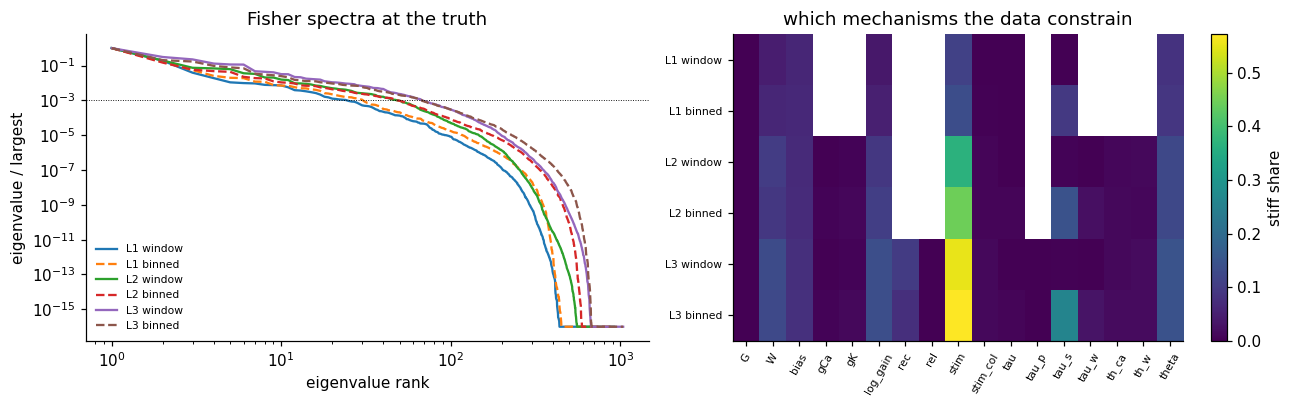

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for (truth, kind), spec in spectra.items():
    ev = spec["evals"] / spec["evals"][0]
    ax[0].semilogy(np.arange(1, len(ev) + 1), np.clip(ev, 1e-16, None), "-" if kind == "window" else "--", label=f"{truth} {kind}")
ax[0].axhline(1e-3, c="k", lw=0.6, ls=":"); ax[0].set_xscale("log")
ax[0].set_xlabel("eigenvalue rank"); ax[0].set_ylabel("eigenvalue / largest"); ax[0].legend(fontsize=7, frameon=False)
ax[0].set_title("Fisher spectra at the truth")
groups = sorted({g for r in fisher_rows for g in r["stiff_share"]})
mat = np.array([[r["stiff_share"].get(g, np.nan) for g in groups] for r in fisher_rows])
im = ax[1].imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=max(0.5, np.nanmax(mat)))
ax[1].set_xticks(range(len(groups))); ax[1].set_xticklabels(groups, rotation=60, fontsize=7)
ax[1].set_yticks(range(len(fisher_rows))); ax[1].set_yticklabels([f"{r['truth']} {r['data']}" for r in fisher_rows], fontsize=7)
plt.colorbar(im, ax=ax[1], label="stiff share"); ax[1].set_title("which mechanisms the data constrain")
plt.tight_layout(); plt.show()

## 3 · Ensemble estimator

If fits are equally good but err in different directions, averaging their predictions estimates the rung's **function** (its input-output map) rather than one arbitrary parameter set. Closure is a claim about function, so this is the appropriate estimator.

* **Member 0** is Notebook 06's fit, reused from its checkpoints.
* **Further members** start from widely spread initializations (`seed = 10000·m`).
* All members use **identical folds**.

The single-fit result is member 0 alone.

In [7]:
ens = {}
for truth in TRUTHS:
    for seed in SEEDS:
        t0 = time.time(); ds_w, _, _ = worm(truth, seed)
        members = [ladder_fit(ds_w, cfg_w, ck06(truth, seed, "window"))[0]]
        for mi in range(1, MEMBERS):
            ck = os.path.join(RESULTS, "e1c_ensemble_ck", MODE, f"{truth}_s{seed}_member{mi}")
            members.append(ladder_fit(ds_w, cfg_w, ck, seed=10000 * mi, fold_seed=0)[0])
        out = {}
        for name, preds in [("single", members[0]), ("ensemble", {L: np.mean([mb[L] for mb in members], 0) for L in LEVELS})]:
            pt, bt = M.bootstrap_feve(preds, ds_w, LEVELS, n_boot=N_BOOT)
            out[name] = dict(point=pt, dec=M.closure_decision(pt, bt), nec=M.necessity(pt, bt))
        ens[(truth, seed)] = out
        print(f"truth {truth} seed {seed}: single L*={out['single']['dec']['L_star']} (needed {out['single']['nec']['L_needed']}), "
              f"ensemble L*={out['ensemble']['dec']['L_star']} (needed {out['ensemble']['nec']['L_needed']}); "
              f"true-rung FEVE {out['single']['point'][truth]:.3f} -> {out['ensemble']['point'][truth]:.3f}  ({(time.time()-t0)/60:.0f} min)")

truth L1 seed 1: single L*=L1 (needed L1), ensemble L*=L1 (needed L1); true-rung FEVE 0.933 -> 0.922  (27 min)
truth L2 seed 1: single L*=L1 (needed L1), ensemble L*=L2 (needed L1); true-rung FEVE 0.766 -> 0.649  (28 min)
truth L3 seed 1: single L*=L3 (needed L1), ensemble L*=L3 (needed L1); true-rung FEVE 0.710 -> 0.652  (28 min)


{
 "L1": {
  "single": {
   "hits": 1,
   "too_deep": 0,
   "true_rung_feve": 0.9331572428597077,
   "L_star": [
    "L1"
   ],
   "L_needed": [
    "L1"
   ]
  },
  "ensemble": {
   "hits": 1,
   "too_deep": 0,
   "true_rung_feve": 0.9219741148758303,
   "L_star": [
    "L1"
   ],
   "L_needed": [
    "L1"
   ]
  }
 },
 "L2": {
  "single": {
   "hits": 0,
   "too_deep": 0,
   "true_rung_feve": 0.7659186832929512,
   "L_star": [
    "L1"
   ],
   "L_needed": [
    "L1"
   ]
  },
  "ensemble": {
   "hits": 1,
   "too_deep": 0,
   "true_rung_feve": 0.6489348432570631,
   "L_star": [
    "L2"
   ],
   "L_needed": [
    "L1"
   ]
  }
 },
 "L3": {
  "single": {
   "hits": 1,
   "too_deep": 0,
   "true_rung_feve": 0.709806318605563,
   "L_star": [
    "L3"
   ],
   "L_needed": [
    "L1"
   ]
  },
  "ensemble": {
   "hits": 1,
   "too_deep": 0,
   "true_rung_feve": 0.6517915921765252,
   "L_star": [
    "L3"
   ],
   "L_needed": [
    "L1"
   ]
  }
 }
}

Registered rule -> ensemble remedy wo

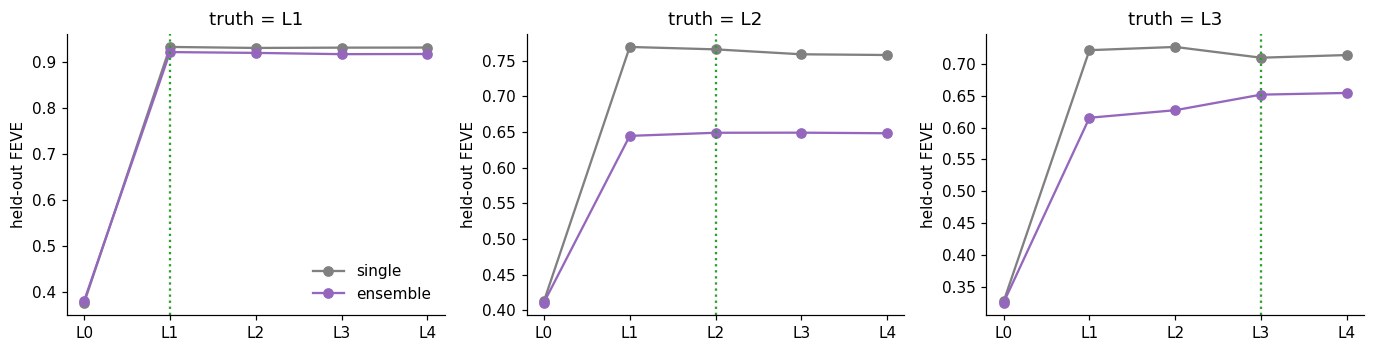

In [8]:
ORDER = {L: i for i, L in enumerate(LADDER)}
summ = {}
for truth in TRUTHS:
    rs = [ens[(truth, s)] for s in SEEDS]
    summ[truth] = {k: dict(hits=int(sum(r[k]["dec"]["L_star"] == truth for r in rs)),
                           too_deep=int(sum(r[k]["dec"]["L_star"] is not None and ORDER[r[k]["dec"]["L_star"]] > ORDER[truth] for r in rs)),
                           true_rung_feve=float(np.mean([r[k]["point"][truth] for r in rs])),
                           L_star=[r[k]["dec"]["L_star"] for r in rs], L_needed=[r[k]["nec"]["L_needed"] for r in rs])
                   for k in ("single", "ensemble")}
deep = [t for t in TRUTHS if t in ("L2", "L3")]
remedy = all(summ[t]["ensemble"]["hits"] > summ[t]["single"]["hits"] for t in deep) and \
         all(summ[t]["ensemble"]["too_deep"] == 0 for t in TRUTHS) and \
         all(summ[t]["ensemble"]["true_rung_feve"] > summ[t]["single"]["true_rung_feve"] for t in TRUTHS)
print(json.dumps(summ, indent=1)); print("\nRegistered rule -> ensemble remedy works:", remedy)
fig, axes = plt.subplots(1, len(TRUTHS), figsize=(4.2 * len(TRUTHS), 3.3), squeeze=False)
for ax, truth in zip(axes[0], TRUTHS):
    for k, c in [("single", "0.5"), ("ensemble", "tab:purple")]:
        ax.plot(range(5), [np.mean([ens[(truth, s)][k]["point"][L] for s in SEEDS]) for L in LADDER], "o-", c=c, label=k)
    ax.axvline(ORDER[truth], ls=":", c="tab:green"); ax.set_xticks(range(5)); ax.set_xticklabels(LADDER)
    ax.set_title(f"truth = {truth}"); ax.set_ylabel("held-out FEVE")
axes[0][0].legend(frameon=False); plt.tight_layout(); plt.show()

## 4 · Real data: the bracket, and how sloppy the real fit is

* **Necessity bracket for E1.** It is computed from Notebook 04's held-out predictions, with no refitting.
* **Sloppiness of the real fit.** This is the Fisher spectrum of the fitted L1 (fold 0) on the real 120-neuron data: how many parameter combinations do the real interventions constrain?

In [9]:
e1_res = json.load(open(os.path.join(RESULTS, "E1_result_laptop.json"))) if os.path.exists(os.path.join(RESULTS, "E1_result_laptop.json")) else None
real_out = {}
if e1_res is not None:
    e1_plan = json.load(open(os.path.join(RESULTS, e1_res["preregistration"]))); c = e1_plan["config"]
    ds_r = real
    if c["n_neurons"] < ds_r.N:
        mk = ds_r.mask()[0]; score = mk.sum(1).astype(float); score[ds_r.stim] += mk.sum(0)
        ds_r = D.subset(ds_r, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    preds_r = dict(np.load(os.path.join(RESULTS, "E1_heldout_predictions_laptop.npz")))
    pt, bt = M.bootstrap_feve(preds_r, ds_r, list(preds_r), n_boot=2000)
    dec_r, nec_r = M.closure_decision(pt, bt), M.necessity(pt, bt)
    print(M.format_decision(dec_r)); print(); print(M.format_necessity(nec_r))
    print(f"\n=> bracket on real data: {nec_r['L_needed']} <= closed level <= {dec_r['L_star']}")
    real_out["bracket"] = [nec_r["L_needed"], dec_r["L_star"]]
    if REAL_FISHER:
        st_r = lad.Structure.from_dataset(ds_r, tie=c["tie_classes"])
        p_r = pickle.load(open(os.path.join(RESULTS, "e1_checkpoints_laptop", "fold0_L1_final.pkl"), "rb"))["params"]
        t0 = time.time()
        spec_r = ID.fisher_spectrum("L1", p_r, ds_r, st_r, lad.SimConfig(**c["sim"]), ~M.kfold_pairs(ds_r, c["k_folds"], c["fold_seed"])[0])
        sr = ID.summarize(spec_r); real_out["fisher"] = dict(sr, stiff_share=ID.group_stiffness(spec_r))
        print(f"\nreal fitted L1: {sr['n_params']} parameters, {sr['n_stiff']} stiff, {sr['decades']:.1f} decades, "
              f"participation {sr['participation']:.1f}  ({(time.time() - t0) / 60:.0f} min)")
        print("stiff share:", {k: round(v, 2) for k, v in real_out["fisher"]["stiff_share"].items()})
else:
    print("Notebook 04 (laptop) results not found; run it first for §4.")

rung   FEVE(held-out)   max upper-CI gain of any deeper rung
L0        0.295         +0.088
L1        0.298         +0.028
L2        0.310         +0.012
L3        0.301         +0.006
L4        0.304            —
=> closed level L* = L1
   B - L*: -0.782 [-1.112, -0.545]  -> black box beats L*: False

rung   gain over best shallower rung [95% CI]   needed?
L1     +0.004 [-0.068, +0.074]               no
L2     -0.000 [-0.056, +0.019]               no
L3     -0.016 [-0.072, +0.008]               no
L4     -0.013 [-0.067, +0.004]               no
=> deepest needed rung L_needed = L0

=> bracket on real data: L0 <= closed level <= L1
  Jacobian columns 64/1961
  Jacobian columns 384/1961
  Jacobian columns 704/1961
  Jacobian columns 1024/1961
  Jacobian columns 1344/1961
  Jacobian columns 1664/1961
  Jacobian columns 1961/1961

real fitted L1: 1961 parameters, 20 stiff, 12.0 decades, participation 1.5  (0 min)
stiff share: {'theta': 0.03, 'bias': 0.02, 'W': 0.01, 'stim': 0.0, 'log_gain

In [10]:
out = {"diagnosis": diag, "fisher": [{k: v for k, v in r.items()} for r in fisher_rows],
       "ensemble": summ, "remedy": bool(remedy), "real": real_out}
json.dump(out, open(os.path.join(RESULTS, f"E1c_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1c_result{TAG}.json")

saved E1c_result_laptop.json


### Results of the `laptop` run (2026-10-06; 60-neuron real wiring; 3 ensemble members)

**§1 — identifiability, not optimization (9 of 9 folds).** No fit has a worse training loss than the truth by more than 0.01 (largest difference: 0.116 vs 0.112). Yet held-out FEVE averages 0.772 for the fits against 1.003 for the truth, ranging from 0.557 to 0.984 across folds.

**§2 — a sloppy model.**

| truth | parameters | stiff (window) | stiff (time course) | spectrum |
|---|---|---|---|---|
| L1 | 678 | 24 | 30 | 12 decades |
| L2 | 919 | 48 | 48 | 12 decades |
| L3 | 1,040 | 68 | 67 | 12 decades |

Only 3–7% of parameter directions are constrained. Time courses add almost nothing (consistent with Notebook 06), and the deeper mechanisms' parameters are essentially unconstrained.

**§3 — ensemble remedy: fails the registered rule.**

| truth | L* single → ensemble | needed (both) | true-rung FEVE single → ensemble |
|---|---|---|---|
| L1 | L1 → L1 | L1 | 0.933 → 0.922 |
| L2 | L1 → L2 | L1 | 0.766 → 0.649 |
| L3 | L3 → L3 | L1 | 0.710 → 0.652 |

The ensemble's L2 "hit" is again a sufficiency artifact of wide confidence intervals; the necessity rule says only L1 is needed.

**Why averaging hurt.** In a follow-up check (truth L2, member 1 refitted), the second member reaches almost the same training loss as the first (0.104 vs 0.097, 0.057 vs 0.056, 0.049 vs 0.046). Its held-out FEVE, however, scatters widely: 0.52 vs 0.81, 0.84 vs 0.62, 0.88 vs 0.88. Equally good fits disagree about unseen interventions, so their average lands near the typical member, not the best one, and can be worse than a lucky single fit. Averaging cannot recover information the experiment does not contain.

**§4 — real data.** The bracket is **L0 ≤ closed ≤ L1**. The real fitted L1 has **20 stiff directions among 1,961 parameters** (participation ratio 1.5), and no mechanism has a stiff share above 0.03. The atlas constrains about a dozen effective numbers, which is why the 246-parameter L0 predicts as well as L1.

## 5 · Reading the result

| finding | consequence |
|---|---|
| fit reaches the truth's training loss but not its held-out accuracy | **identifiability, not optimization**: more training or better optimizers will not help; only more informative interventions or stronger priors will |
| few stiff directions, deeper mechanisms (gK, gCa, rec, …) not among them | interventions on single neurons, read out as amplitudes or time courses, cannot constrain these mechanisms. This explains Notebooks 02 and 06. |
| ensemble remedy works | estimate rungs by their **function**, averaging non-identified fits: use ensembles in E1, E3 and Closure-Bench |
| ensemble does not recover the truth ← **this run** | the information is not in this kind of data at all; E1's statement is the bracket, not a single closed level. The constructive next step is to **design experiments that add the missing information** (Notebook 08). |

**Conceptual note for the proposal.** If the data constrain only a few stiff parameter combinations, then the "software" is those combinations, and the rest is microdetail that intervention data cannot see. That is a version of Machta et al.'s parameter-space compression. It suggests reframing C2: a level is closed if its *stiff* subspace predicts interventions. Whether its individual parameters are recoverable is beside the point.